# Generalized Integrate-and-Fire Neuron

In [1]:
#!pip install ANNarchy

This notebook explores the generalized Integrate-and-Fire neuron model being used in CUBA-like network. This network has been proposed in

> Brette, R., Rudolph, M., Carnevale, T., Hines, M., Beeman, D., Bower, J. M., et al. (2007), Simulation of networks of spiking neurons: a review of tools and strategies., *J. Comput. Neurosci., 23, 3, 349–98*

as benchmark and is based on:

> Vogels, T. P. and Abbott, L. F. (2005), Signal propagation and logic gating in networks of integrate-and-fire neurons., *J. Neurosci., 25, 46, 10786–95*

However, in this notebook, we don't use a standard LIF model, but the generalized IaF neuron described in:

> Schwalger, T., Deger, M., Gerstner, w. (2017). Towards a theory of cortical columns: From spiking neurons to interacting neural populations of finite size. PLoS Comput Biol. 2017;13(4):e1005507


In [2]:
import matplotlib.pyplot as plt
import numpy

import ANNarchy as ann

ANNarchy 5.0 (5.0.1) on linux (posix).


The generalized leaky Integrate-and-Fire neuron is defined by the following equations:

$$
    \tau_m \frac{du}{dt} = -u + u_r + R*(I_{ext} + I_{exc} + I_{inh})
$$

$$
    \tau_v \frac{dv}{dt} = -(v-u_{th})
$$

Spike emission is the result of a stochastic process, where the threshold $\lambda$, also called hazard-rate, follows the difference between the membrane potential $u$ and an adaptive threshold $v$:

$$
    \lambda = c * exp(\frac{u-v}{\delta_{u}})
$$

This could be implemented in ANNarchy like the following. Note that we split the pre-synaptic inputs (*syn*) into excitatory (*exc*) and inhibitory (*inh*). We also added an exponential decay on the inputs, with the time constants $\tau_{g_{exc}}$ and $\tau_{g_{inh}}$.

In [3]:
GIF = ann.Neuron(
    # Values are partially taken from Schwalger et al. (2017), Table 1
    # Values related to synaptic inputs are derived from Vogels & Abbott (2005)
    parameters=dict(
        tau_m       =   10.0,
        tau_v       = 1000.0,
        J_v         = 1000.0,
        u_r         =  -65.0,
        u_th        =  -50.0,
        R           =   0.04, # R_ext = tau_m / C = 10ms / 250 pA
        c           =   10.0,
        delta_u     =    5.0,
        # synaptic inputs
        tau_g_exc   =    5.0,
        tau_g_inh   =   10.0,
        I_ext       =  375.0
    ),
    equations=[
        # membrane potential
        ann.Variable("tau_m * du/dt = -u + u_r + R*(I_ext + g_exc + g_inh)", init='u_r'),
        # adaptive spike threshold, v is incremented by each spike, otherwise decays toward u_t
        ann.Variable("tau_v * dv/dt = -(v-u_th)", init='u_th'),
        # escape rate in Hz, resp. spikes/s
        ann.Variable("Lambda = c * exp((u-v)/delta_u)"),
        # Note: we need to map from ms -> s, that it fits to rate in Hz
        ann.Variable("p = Uniform(0.0, 1.0) * 1000.0 / dt"),
        # external input
        ann.Variable("tau_g_exc * dg_exc/dt = -g_exc"),
        ann.Variable("tau_g_inh * dg_inh/dt = -g_inh"),
    ],
    spike = "p < Lambda",
    reset = """
        u = u_r
        v += J_v/tau_v
    """,
    refractory = 5.0
)

In the following we construct a CUBA like network, inspired by the work of Vogels and Abbott (2005). Adapted the parameters of the GIF neuron model to obtain comparable statistics.

In [ ]:
class COBANetwork (ann.Network):
    
    def __init__(self, w_exc, w_inh):

        self.P = self.create(geometry=4000, neuron=COBA)
        self.P.v     = ann.Normal(-55.0, 5.0)
        self.P.g_exc = ann.Normal(4.0,   1.5)
        self.P.g_inh = ann.Normal(20.0, 12.0)

        self.P[:3200].Jv = 1500 # mv/ms
        self.P[3200:].Jv = 0    # mv/ms, no adaptation for inhibitory cells
        
        self.Ce = self.connect(pre=self.P[:3200], post=self.P, target='exc')
        self.Ce.fixed_probability(weights=w_exc, probability=0.02)

        self.Ci = self.connect(pre=self.P[3200:], post=self.P, target='inh')
        self.Ci.fixed_probability(weights=w_inh, probability=0.02)

        self.m = self.monitor(self.P, ['spike'])

In [4]:
class CUBANetwork (ann.Network):
    
    def __init__(self, w_exc, w_inh):

        self.P = self.create(geometry=4000, neuron=GIF)

        self.P[:3200].Jv = 1500 # mv/ms
        self.P[3200:].Jv = 0    # mv/ms, no adaptation for inhibitory cells
        
        self.Ce = self.connect(pre=self.P[:3200], post=self.P, target='exc')
        self.Ce.fixed_probability(weights=w_exc, probability=0.02)

        self.Ci = self.connect(pre=self.P[3200:], post=self.P, target='inh')
        self.Ci.fixed_probability(weights=w_inh, probability=0.02)

        self.m = self.monitor(self.P, ['spike'])

In [5]:
# CUBA network
we_CUBA = 1.62
wi_CUBA = 9.0

net_cuba = CUBANetwork(w_exc=we_CUBA, w_inh=wi_CUBA, dt=0.1)
net_cuba.compile()


In [6]:
net_cuba.simulate(1000., measure_time=True)

Simulating 1.0 seconds of the network 1 took 0.9028279781341553 seconds.


In [7]:
data_CUBA = net_cuba.m.get('spike')

In [8]:
t_CUBA, n_CUBA = net_cuba.m.raster_plot(data_CUBA)

In [9]:
print('Mean firing rate in the COBA population: ' + str(len(t_CUBA) / 4000.) + 'Hz')

Mean firing rate in the COBA population: 6.055Hz


Text(0, 0.5, '# neuron')

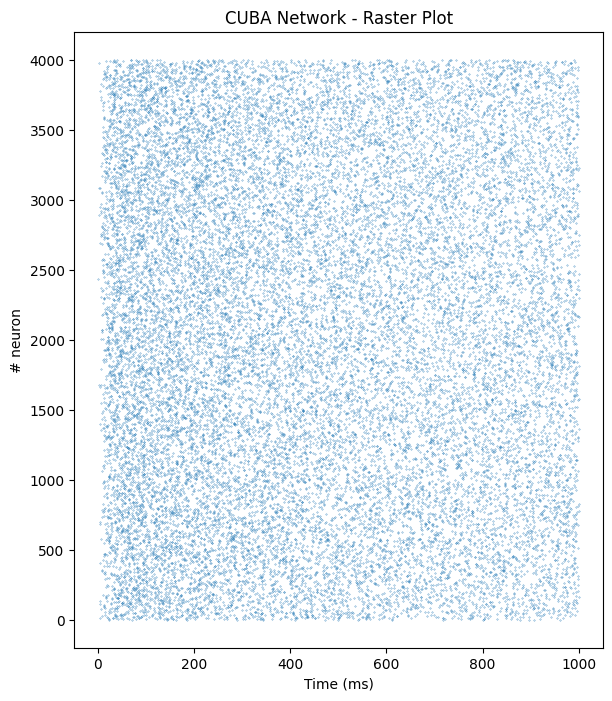

In [10]:
plt.figure(figsize=(15, 8))
plt.subplot(121)
plt.title("CUBA Network - Raster Plot")
plt.plot(t_CUBA, n_CUBA, '.', markersize=0.5)
plt.xlabel('Time (ms)')
plt.ylabel('# neuron')

In [11]:
isi_CUBA = net_cuba.m.inter_spike_interval(data_CUBA)

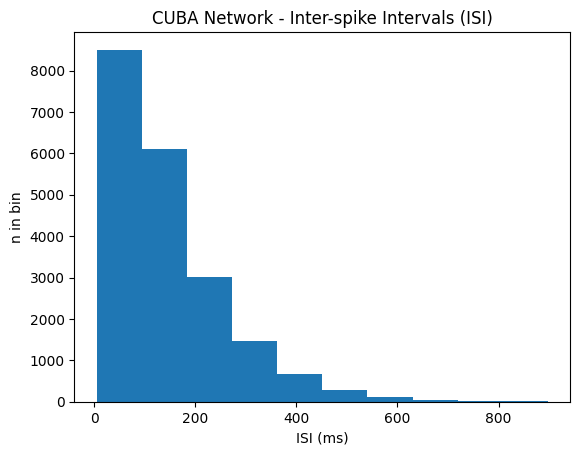

In [12]:
plt.title("CUBA Network - Inter-spike Intervals (ISI)")
plt.hist(isi_CUBA)
plt.xlabel('ISI (ms)')
plt.ylabel('n in bin')
plt.show()

In [13]:
cov_CUBA = net_cuba.m.coefficient_of_variation(data_CUBA)

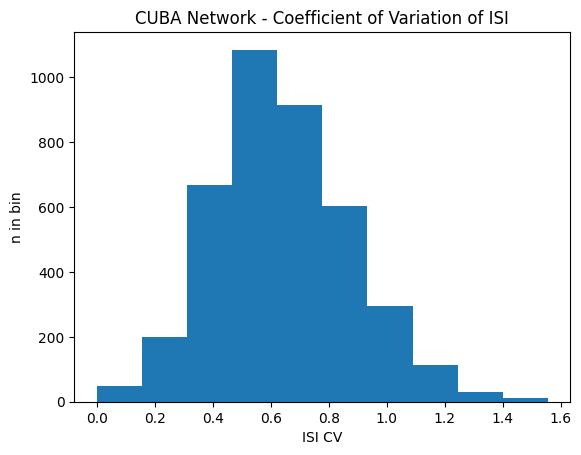

In [14]:
plt.title("CUBA Network - Coefficient of Variation of ISI")
plt.hist(cov_CUBA)
plt.xlabel('ISI CV')
plt.ylabel('n in bin')
plt.show()